## 1. Setup & Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# ── File path — update this if you move the CSV ───────────────────────────
# DATA_PATH = r"C:\Users\User\OneDrive\Documents\OVGU\1st sem\HCAI\fedmml_ed_triage_dataset.csv"
SAVE_DIR  = '/content/' # Defined for Colab environment

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        11,
})
GREEN  = '#2ecc71'
RED    = '#e74c3c'
BLUE   = '#3498db'
ORANGE = '#f39c12'

print("✅ Libraries loaded")
# print(f"📂 Data path : {DATA_PATH}")
# print(f"💾 Save dir  : {SAVE_DIR}")

✅ Libraries loaded


In [ ]:
DATA_PATH='/content/drive/MyDrive/med_data/fedmml_ed_triage_dataset.csv'

In [ ]:
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape : {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
print(f"Memory usage  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head()


Dataset shape : 87,234 rows  ×  28 columns
Memory usage  : 59.2 MB


,encounter_id,patient_id,site_id,country,age,sex,arrival_timestamp,chief_complaint,clinical_notes,systolic_bp,...,platelet_count,sodium,potassium,creatinine,glucose,troponin,bnp,lactate,inr,esi_level
0,ENC1000001,PAT000001,1,Denmark,59,F,2021-01-30 12:33:00,Back pain,NaN,122.0,...,244.0,142.1,3.77,0.74,75.0,0.0,65.0,1.13,1.01,3
1,ENC1000002,PAT000002,1,Denmark,67,M,2022-02-26 01:46:00,Medication question,67yo M requesting Medication question. Patient...,138.0,...,242.0,138.4,4.09,1.15,84.0,0.0,85.0,1.24,0.68,5
2,ENC1000003,PAT000003,1,Denmark,58,F,2021-10-20 08:55:00,Cold symptoms,"58yo F here for Cold symptoms. Patient stable,...",114.0,...,296.0,139.0,3.82,1.11,111.0,0.0,56.0,0.94,1.12,4
3,ENC1000004,PAT000004,1,Denmark,23,F,2021-01-11 20:11:00,Laceration requiring sutures,23yo F presents with Laceration requiring sutu...,137.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
4,ENC1000005,PAT000005,1,Denmark,64,F,2023-11-05 13:44:00,Chest pain,64yo F c/o Chest pain. Patient in moderate dis...,141.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2


## 2. Dataset Overview

In [ ]:
# Column catalogue — dtype, missing count, unique values, sample value
schema = pd.DataFrame({
    'dtype'    : df.dtypes,
    'missing'  : df.isnull().sum(),
    'missing%' : (df.isnull().mean() * 100).round(1),
    'n_unique' : df.nunique(),
    'sample'   : [df[c].dropna().iloc[0] if df[c].dropna().shape[0] else 'N/A'
                  for c in df.columns]
})
print("Column Catalogue:")
schema


Column Catalogue:


,dtype,missing,missing%,n_unique,sample
encounter_id,object,0,0.0,87234,ENC1000001
patient_id,object,0,0.0,96,PAT000001
site_id,int64,0,0.0,6,1
country,object,0,0.0,3,Denmark
age,int64,0,0.0,83,59
sex,object,0,0.0,2,F
arrival_timestamp,object,0,0.0,85466,2021-01-30 12:33:00
chief_complaint,object,0,0.0,28,Back pain
clinical_notes,object,1555,1.8,4231,67yo M requesting Medication question. Patient...
systolic_bp,float64,5492,6.3,177,122.0


In [ ]:
print("Numeric summary:")
df.describe().T


Numeric summary:


,count,mean,std,min,25%,50%,75%,max
site_id,87234.0,3.274010,1.722482,1.000,2.00,3.00,5.00,6.000
age,87234.0,51.923654,18.102583,18.000,39.00,52.00,64.00,100.000
systolic_bp,81742.0,129.690551,18.016627,43.000,118.00,128.00,140.00,229.000
diastolic_bp,81742.0,82.136919,11.280634,3.000,75.00,82.00,89.00,141.000
heart_rate,81742.0,87.158278,16.616061,31.000,76.00,86.00,97.00,183.000
respiratory_rate,81742.0,18.132992,3.852378,2.000,16.00,18.00,20.00,44.000
temperature,81742.0,37.472881,0.737290,34.000,37.00,37.30,37.90,41.300
spo2,81742.0,95.971112,2.813958,75.400,94.50,96.60,98.00,105.100
pain_score,81742.0,4.458809,2.158720,0.000,3.00,5.00,6.00,10.000
wbc,60631.0,8.291628,2.840701,-0.960,6.41,7.96,9.73,25.260


## 3. Data Quality Audit — Missing Values

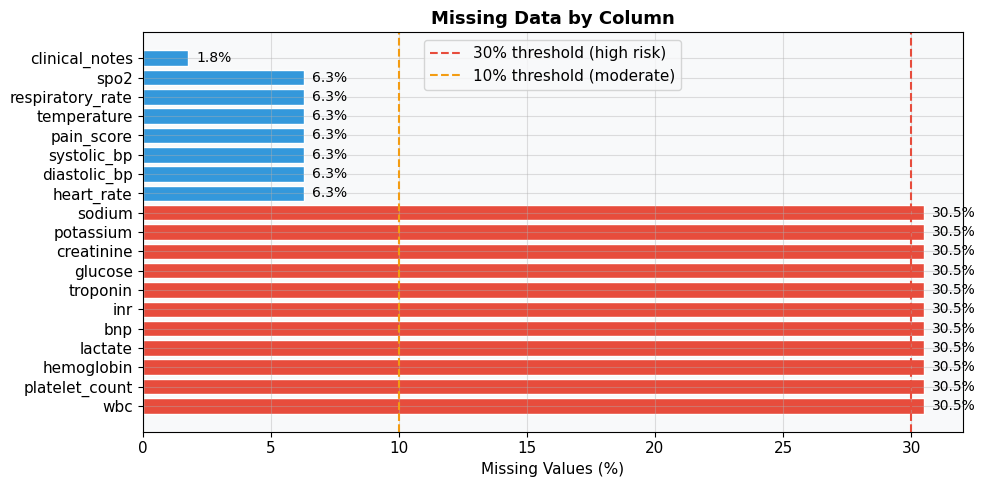


📌 Observations:
  • Vitals group  (HR, BP, RR, Temp, SpO2, pain_score) — ~6.3% missing
    → Likely not collected in some triage entries
  • Labs group    (WBC, lactate, creatinine, etc.)     — ~30.5% missing
    → Labs are ordered AFTER triage, so high missingness is expected
  • ESI level, demographics                           — 0% missing ✅


In [ ]:
missing = df.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [RED if v > 30 else ORANGE if v > 10 else BLUE for v in missing.values]
bars   = ax.barh(missing.index, missing.values, color=colors, edgecolor='white')

for bar, val in zip(bars, missing.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.axvline(30, color=RED,    ls='--', lw=1.5, label='30% threshold (high risk)')
ax.axvline(10, color=ORANGE, ls='--', lw=1.5, label='10% threshold (moderate)')
ax.set_xlabel('Missing Values (%)')
ax.set_title('Missing Data by Column', fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 Observations:")
print("  • Vitals group  (HR, BP, RR, Temp, SpO2, pain_score) — ~6.3% missing")
print("    → Likely not collected in some triage entries")
print("  • Labs group    (WBC, lactate, creatinine, etc.)     — ~30.5% missing")
print("    → Labs are ordered AFTER triage, so high missingness is expected")
print("  • ESI level, demographics                           — 0% missing ✅")


## 4. Target Variable — ESI Level Distribution

In [ ]:
esi_counts = df['esi_level'].value_counts().sort_index()
esi_labels = {
    1: 'ESI-1\nImmediate',
    2: 'ESI-2\nEmergent',
    3: 'ESI-3\nUrgent',
    4: 'ESI-4\nLess Urgent',
    5: 'ESI-5\nNon-Urgent'
}
colors_esi = [RED, '#e67e22', ORANGE, BLUE, GREEN]

# fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# # Bar chart
# bars = axes[0].bar(
#     [esi_labels[i] for i in esi_counts.index],
#     esi_counts.values,
#     color=colors_esi, edgecolor='white', linewidth=1.2
# )
# for bar, val in zip(bars, esi_counts.values):
#     axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
#                  f'{val:,}', ha='center', fontweight='bold', fontsize=10)
# axes[0].set_title('ESI Level — Count', fontweight='bold')
# axes[0].set_ylabel('Patient Count')

# # Pie chart
# axes[1].pie(
#     esi_counts.values,
#     labels=[esi_labels[i] for i in esi_counts.index],
#     colors=colors_esi, autopct='%1.1f%%', startangle=90,
#     wedgeprops={'edgecolor': 'white', 'linewidth': 2}
# )
# axes[1].set_title('ESI Level — Proportions', fontweight='bold')

# plt.suptitle(f'ESI Level Distribution  (n = {len(df):,})', fontsize=13,
#              fontweight='bold', y=1.01)
# plt.tight_layout()
# plt.savefig(SAVE_DIR + 'fig_esi_distribution.png', dpi=150, bbox_inches='tight')
# plt.show()

print("\n📌 ESI-3 dominates at 47% — expected in real emergency departments.")
print("   ESI-1 (immediate) is rare at ~1%, which reflects real-world ED patterns.")


📌 ESI-3 dominates at 47% — expected in real emergency departments.
   ESI-1 (immediate) is rare at ~1%, which reflects real-world ED patterns.


## 5. Sepsis Label Engineering

The dataset has **no explicit sepsis column**, so we derive a binary `sepsis_flag`
using a **qSOFA + Sepsis-3** hybrid rule — the same logic used clinically at ED bedsides.

| Criterion | Threshold | qSOFA Points |
|-----------|-----------|-------------|
| Altered mental status | Chief complaint contains confusion/LOC keywords | +1 |
| Respiratory Rate | ≥ 22 /min | +1 |
| Systolic BP | ≤ 100 mmHg | +1 |

> **`sepsis_flag = 1`** when **qSOFA score ≥ 2**  
> **OR** **lactate ≥ 2.0 mmol/L** (Sepsis-3 criterion)


In [ ]:
# ── qSOFA Component 1: Altered mentation (from chief complaint text) ───────
mental_keywords = [
    'confusion', 'altered', 'unresponsive', 'drowsy',
    'lethargic', 'high fever with confusion', 'stroke symptoms'
]
df['altered_mentation'] = (
    df['chief_complaint'].str.lower()
    .str.contains('|'.join(mental_keywords), na=False)
    .astype(int)
)

# ── qSOFA Component 2: High respiratory rate ───────────────────────────────
df['rr_high'] = (df['respiratory_rate'] >= 22).astype(int)

# ── qSOFA Component 3: Low systolic blood pressure ────────────────────────
df['sbp_low'] = (df['systolic_bp'] <= 100).astype(int)

# ── qSOFA total score (0–3) ────────────────────────────────────────────────
df['qsofa_score'] = df['altered_mentation'] + df['rr_high'] + df['sbp_low']

# ── Lactate criterion (Sepsis-3) ───────────────────────────────────────────
df['lactate_high'] = (df['lactate'] >= 2.0).astype(int)

# ── Final sepsis flag ──────────────────────────────────────────────────────
df['sepsis_flag'] = (
    (df['qsofa_score'] >= 2) | (df['lactate_high'] == 1)
).astype(int)

# ── Summary ───────────────────────────────────────────────────────────────
pos = df['sepsis_flag'].sum()
neg = len(df) - pos
print(f"Sepsis positive : {pos:,}  ({pos / len(df) * 100:.1f}%)")
print(f"Sepsis negative : {neg:,}  ({neg / len(df) * 100:.1f}%)")
print(f"Class ratio     : 1 : {neg / pos:.1f}")
print(f"\nNew columns added: altered_mentation, rr_high, sbp_low, qsofa_score, lactate_high, sepsis_flag")


Sepsis positive : 8,865  (10.2%)
Sepsis negative : 78,369  (89.8%)
Class ratio     : 1 : 8.8

New columns added: altered_mentation, rr_high, sbp_low, qsofa_score, lactate_high, sepsis_flag


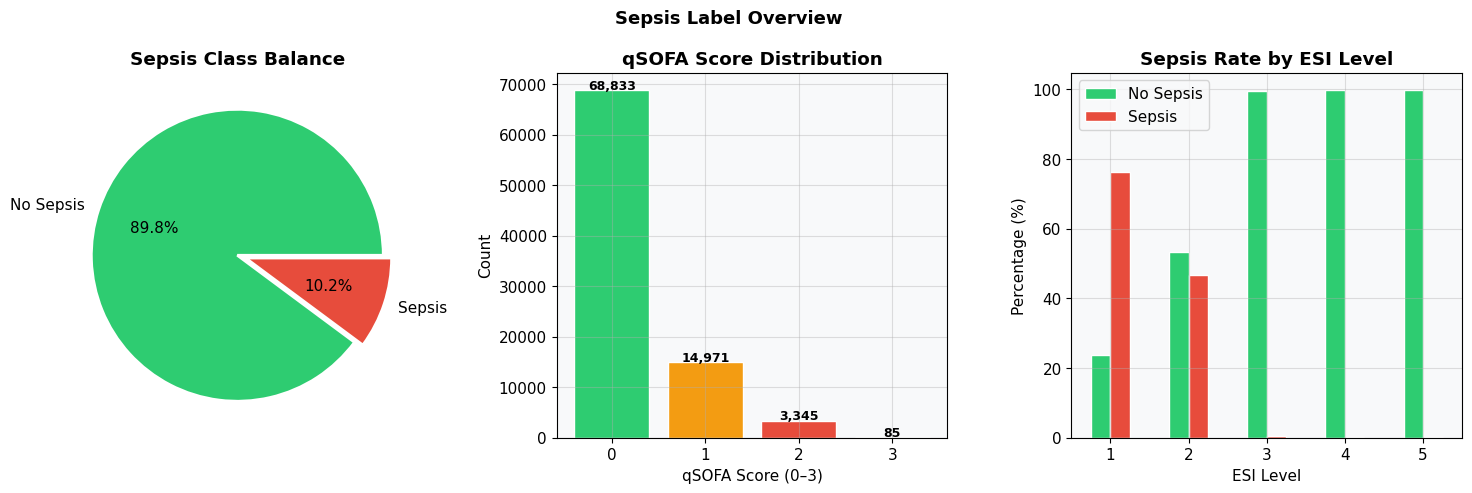


📌 Sepsis rate rises sharply at ESI-1 and ESI-2 — confirms label quality.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Class balance pie
axes[0].pie([neg, pos], labels=['No Sepsis', 'Sepsis'],
            colors=[GREEN, RED], autopct='%1.1f%%', explode=(0, 0.06),
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Sepsis Class Balance', fontweight='bold')

# qSOFA score distribution
qsofa_counts = df['qsofa_score'].value_counts().sort_index()
bar_colors   = [GREEN, ORANGE, RED, '#8e44ad']
axes[1].bar(qsofa_counts.index, qsofa_counts.values,
            color=bar_colors[:len(qsofa_counts)], edgecolor='white')
for i, (idx, val) in enumerate(qsofa_counts.items()):
    axes[1].text(idx, val + 200, f'{val:,}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('qSOFA Score (0–3)')
axes[1].set_ylabel('Count')
axes[1].set_title('qSOFA Score Distribution', fontweight='bold')
axes[1].set_xticks([0, 1, 2, 3])

# Sepsis rate by ESI level
cross = pd.crosstab(df['esi_level'], df['sepsis_flag'], normalize='index') * 100
cross.columns = ['No Sepsis', 'Sepsis']
cross.plot(kind='bar', ax=axes[2], color=[GREEN, RED], edgecolor='white', rot=0)
axes[2].set_xlabel('ESI Level')
axes[2].set_ylabel('Percentage (%)')
axes[2].set_title('Sepsis Rate by ESI Level', fontweight='bold')
axes[2].legend()

plt.suptitle('Sepsis Label Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_sepsis_label.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 Sepsis rate rises sharply at ESI-1 and ESI-2 — confirms label quality.")


## 6. EDA — Vital Signs vs Sepsis Flag

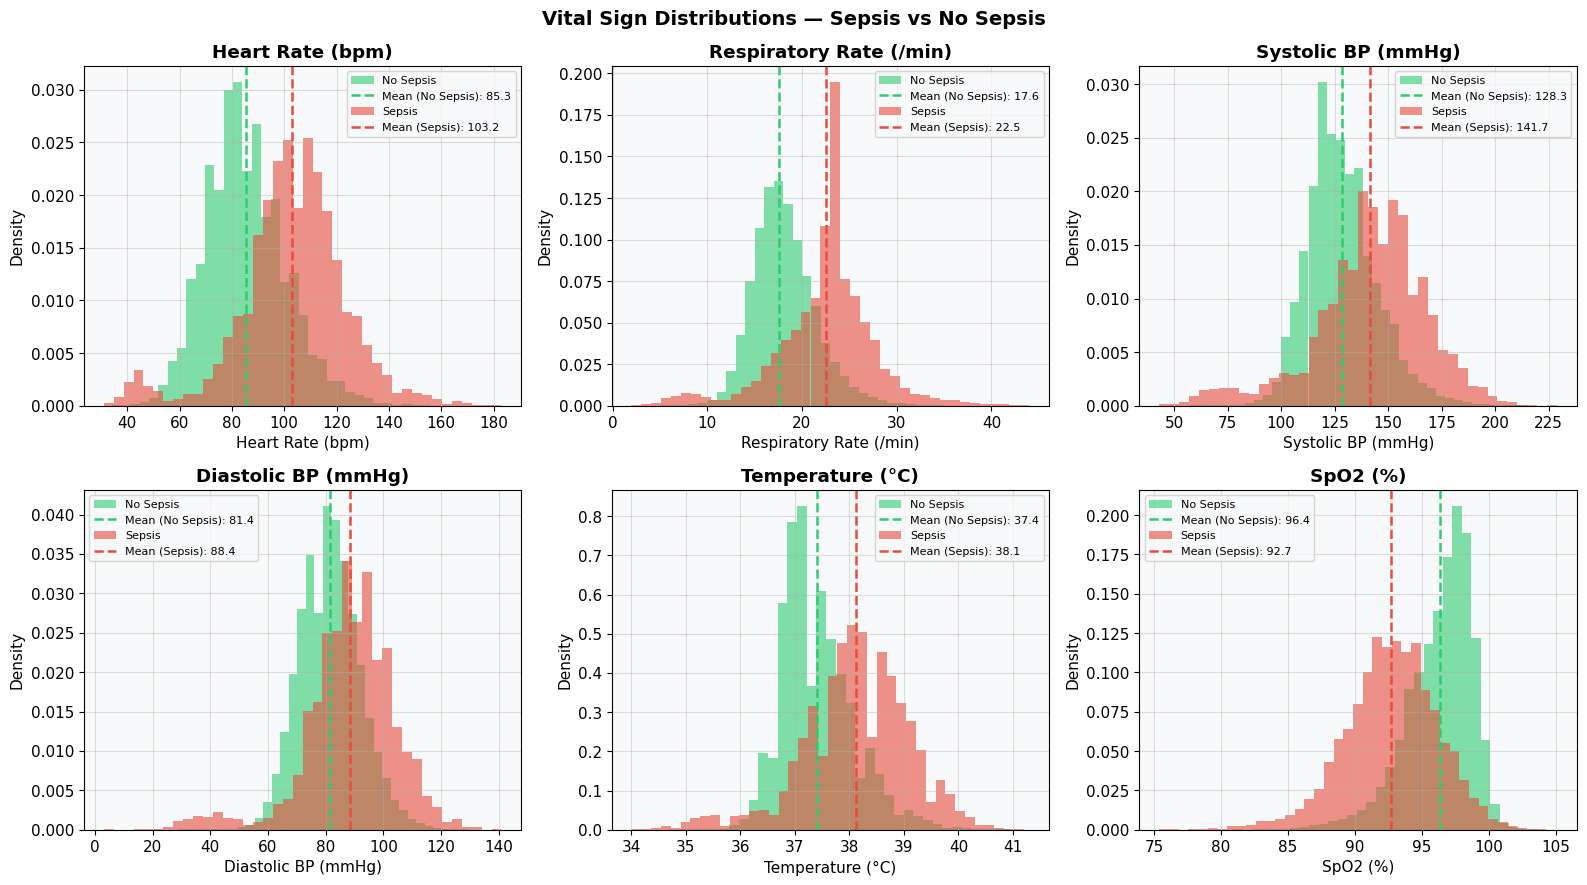

In [ ]:
vitals = ['heart_rate', 'respiratory_rate', 'systolic_bp',
          'diastolic_bp', 'temperature', 'spo2']
vital_labels = ['Heart Rate (bpm)', 'Respiratory Rate (/min)',
                'Systolic BP (mmHg)', 'Diastolic BP (mmHg)',
                'Temperature (°C)', 'SpO2 (%)']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col, label in zip(axes, vitals, vital_labels):
    for flag, color, name in [(0, GREEN, 'No Sepsis'), (1, RED, 'Sepsis')]:
        data = df.loc[df['sepsis_flag'] == flag, col].dropna()
        ax.hist(data, bins=40, alpha=0.6, color=color, label=name, density=True)
        ax.axvline(data.mean(), color=color, ls='--', lw=1.8,
                   label=f'Mean ({name}): {data.mean():.1f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Vital Sign Distributions — Sepsis vs No Sepsis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_vitals_eda.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. EDA — Lab Values vs Sepsis Flag

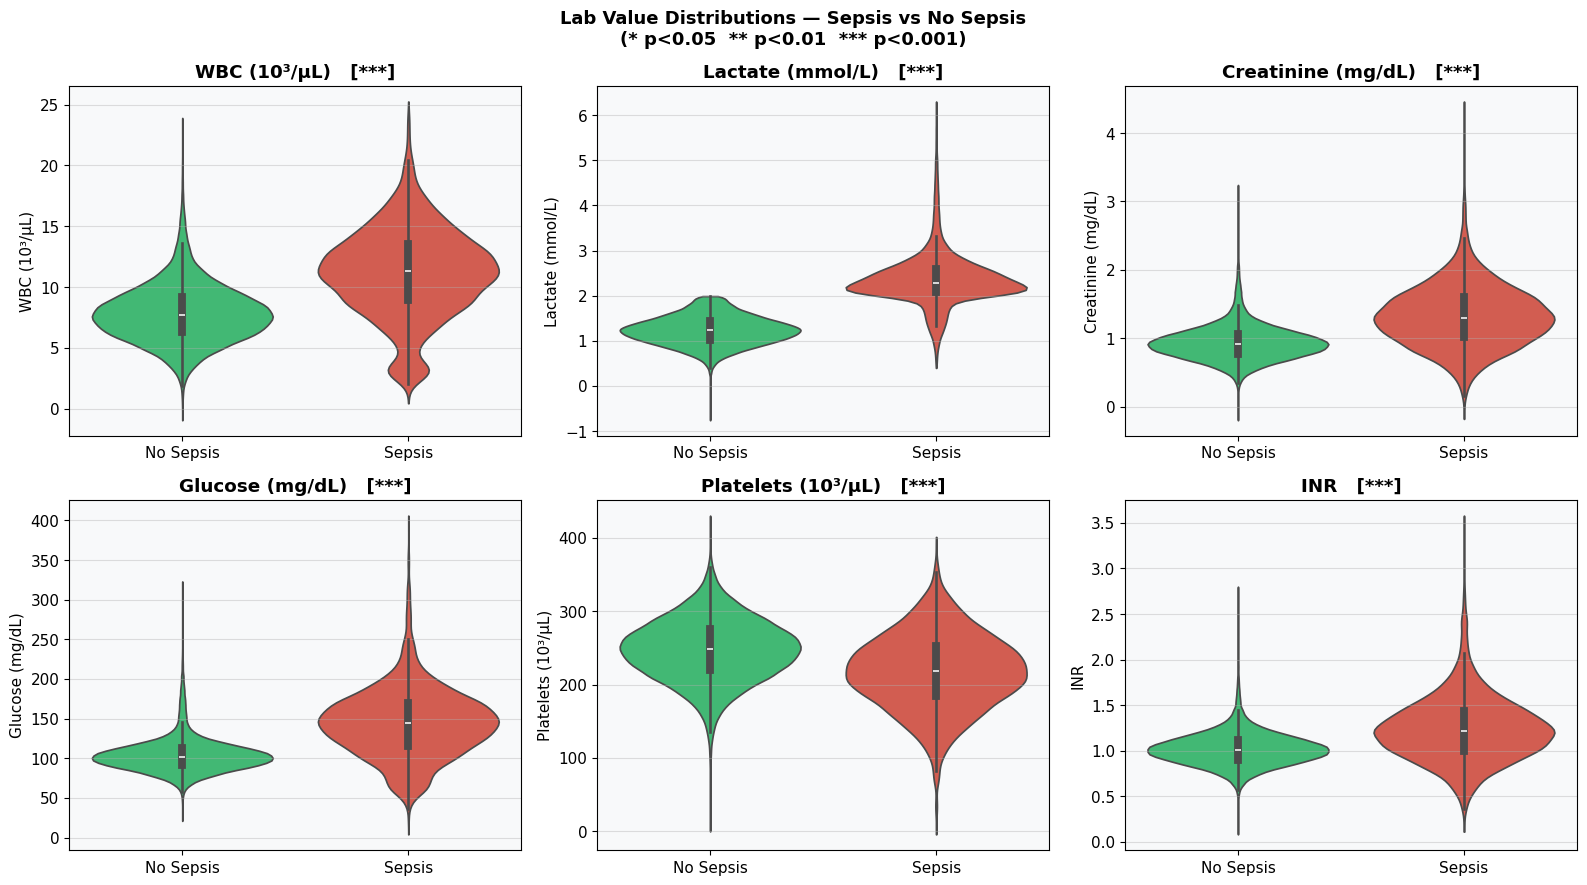

In [ ]:
labs       = ['wbc', 'lactate', 'creatinine', 'glucose', 'platelet_count', 'inr']
lab_labels = ['WBC (10³/µL)', 'Lactate (mmol/L)', 'Creatinine (mg/dL)',
              'Glucose (mg/dL)', 'Platelets (10³/µL)', 'INR']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col, label in zip(axes, labs, lab_labels):
    subset = df[['sepsis_flag', col]].dropna().copy()
    subset['Sepsis Status'] = subset['sepsis_flag'].map({0: 'No Sepsis', 1: 'Sepsis'})
    pal = {'No Sepsis': GREEN, 'Sepsis': RED}

    sns.violinplot(data=subset, x='Sepsis Status', y=col,
                   palette=pal, inner='box', cut=0, ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel(label)

    # Mann-Whitney U test for statistical significance
    g0 = subset.loc[subset['sepsis_flag'] == 0, col]
    g1 = subset.loc[subset['sepsis_flag'] == 1, col]
    _, pval = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    ax.set_title(f'{label}   [{stars}]', fontweight='bold')

plt.suptitle('Lab Value Distributions — Sepsis vs No Sepsis\n(* p<0.05  ** p<0.01  *** p<0.001)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_labs_eda.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. EDA — Demographics vs Sepsis Flag

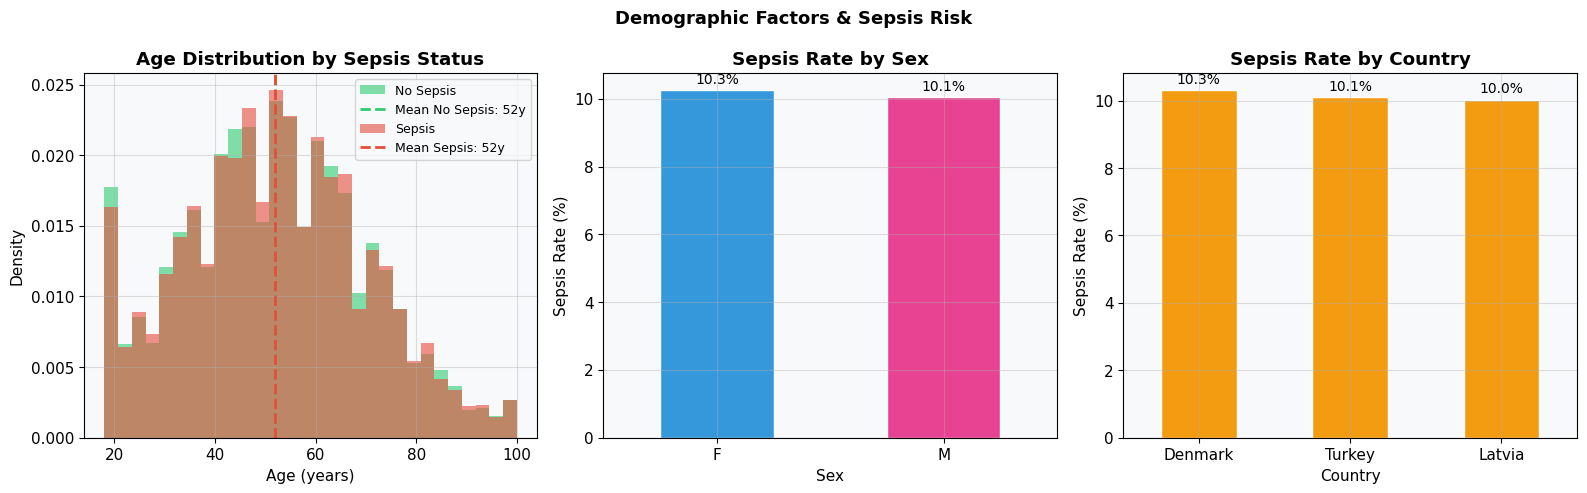

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age distribution
for flag, color, name in [(0, GREEN, 'No Sepsis'), (1, RED, 'Sepsis')]:
    data = df.loc[df['sepsis_flag'] == flag, 'age']
    axes[0].hist(data, bins=30, alpha=0.6, color=color, label=name, density=True)
    axes[0].axvline(data.mean(), color=color, ls='--', lw=2,
                    label=f'Mean {name}: {data.mean():.0f}y')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Density')
axes[0].set_title('Age Distribution by Sepsis Status', fontweight='bold')
axes[0].legend(fontsize=9)

# Sex vs sepsis rate
sex_sepsis = pd.crosstab(df['sex'], df['sepsis_flag'], normalize='index') * 100
sex_sepsis.columns = ['No Sepsis %', 'Sepsis %']
sex_sepsis['Sepsis %'].plot(kind='bar', ax=axes[1],
    color=[BLUE, '#e84393'], edgecolor='white', rot=0)
axes[1].set_title('Sepsis Rate by Sex', fontweight='bold')
axes[1].set_ylabel('Sepsis Rate (%)')
axes[1].set_xlabel('Sex')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10)

# Country vs sepsis rate
country_sepsis = pd.crosstab(df['country'], df['sepsis_flag'], normalize='index') * 100
country_sepsis[1].sort_values(ascending=False).plot(
    kind='bar', ax=axes[2], color=ORANGE, edgecolor='white', rot=0)
axes[2].set_title('Sepsis Rate by Country', fontweight='bold')
axes[2].set_ylabel('Sepsis Rate (%)')
axes[2].set_xlabel('Country')
for bar in axes[2].patches:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10)

plt.suptitle('Demographic Factors & Sepsis Risk', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_demographics_eda.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Correlation Matrix

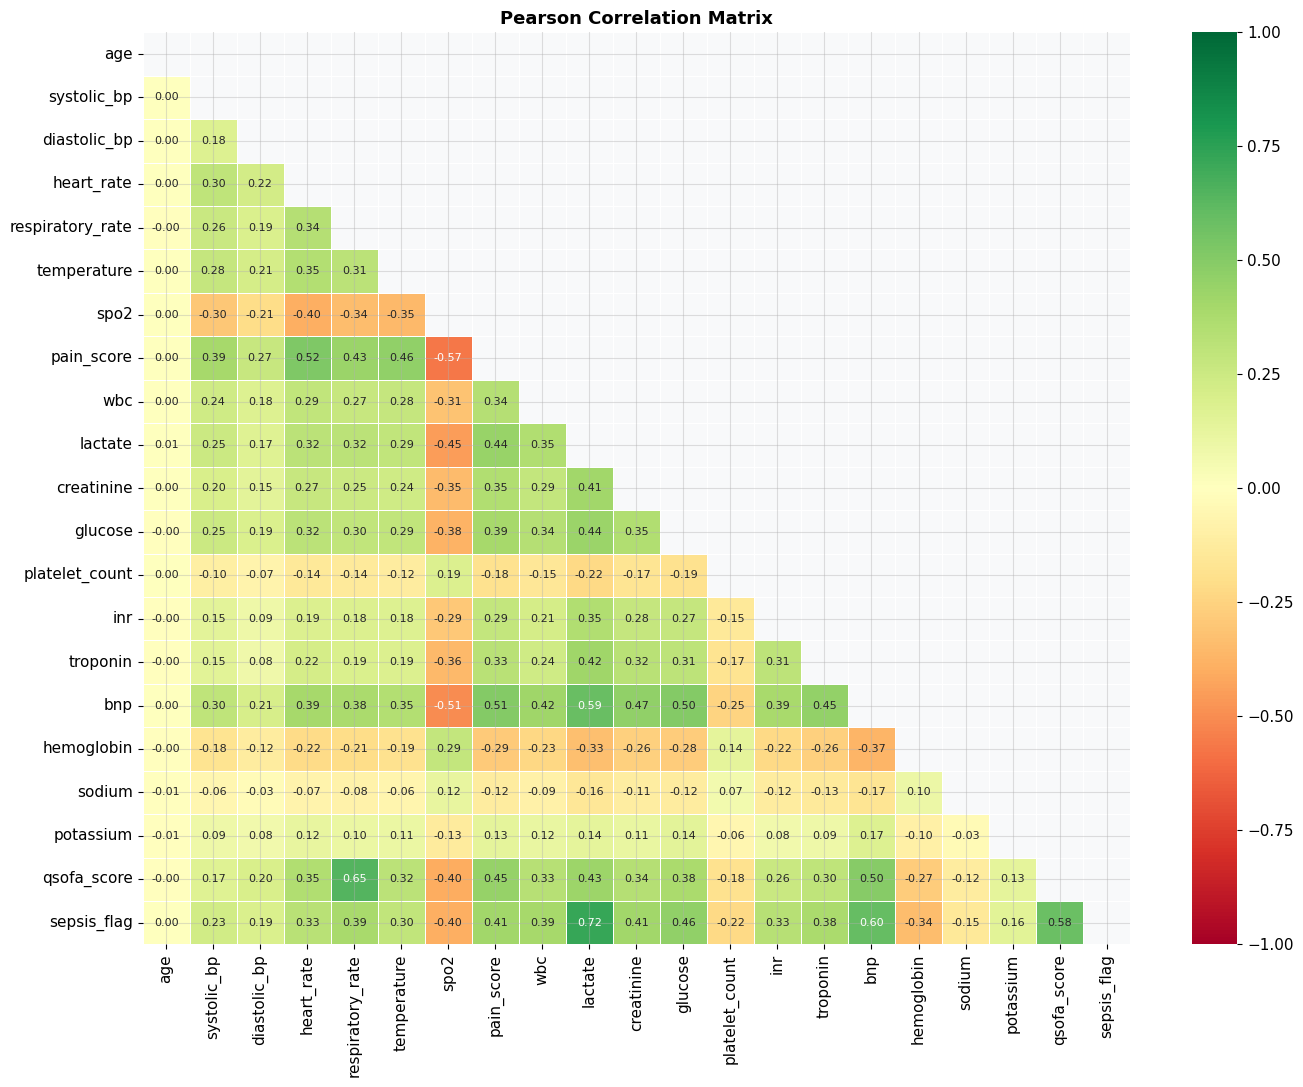


🔗 Top correlations with sepsis_flag:
  ▲ positive  lactate                 r = +0.720
  ▲ positive  bnp                     r = +0.601
  ▲ positive  qsofa_score             r = +0.585
  ▲ positive  glucose                 r = +0.461
  ▲ positive  creatinine              r = +0.411
  ▲ positive  pain_score              r = +0.407
  ▼ negative  spo2                    r = -0.396
  ▲ positive  wbc                     r = +0.392
  ▲ positive  respiratory_rate        r = +0.387
  ▲ positive  troponin                r = +0.382


In [ ]:
num_cols = [
    'age', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'respiratory_rate',
    'temperature', 'spo2', 'pain_score', 'wbc', 'lactate', 'creatinine',
    'glucose', 'platelet_count', 'inr', 'troponin', 'bnp', 'hemoglobin',
    'sodium', 'potassium', 'qsofa_score', 'sepsis_flag'
]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8},
            vmin=-1, vmax=1)
ax.set_title('Pearson Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with sepsis_flag
print("\n🔗 Top correlations with sepsis_flag:")
top_corr = corr['sepsis_flag'].drop('sepsis_flag').abs().sort_values(ascending=False)
for feat, val in top_corr.head(10).items():
    direction = '▲ positive' if corr.loc[feat, 'sepsis_flag'] > 0 else '▼ negative'
    print(f"  {direction}  {feat:<22}  r = {corr.loc[feat, 'sepsis_flag']:+.3f}")


## 10. Data-Driven Feature Importance — Random Forest

✅ Random Forest trained on 10-feature set

Feature Importance Ranking:
          feature  importance
      qsofa_score    0.280747
             spo2    0.143602
 respiratory_rate    0.134589
          rr_high    0.113964
       heart_rate    0.112662
altered_mentation    0.101344
      temperature    0.058328
      systolic_bp    0.047556
              age    0.004030
          sbp_low    0.003179


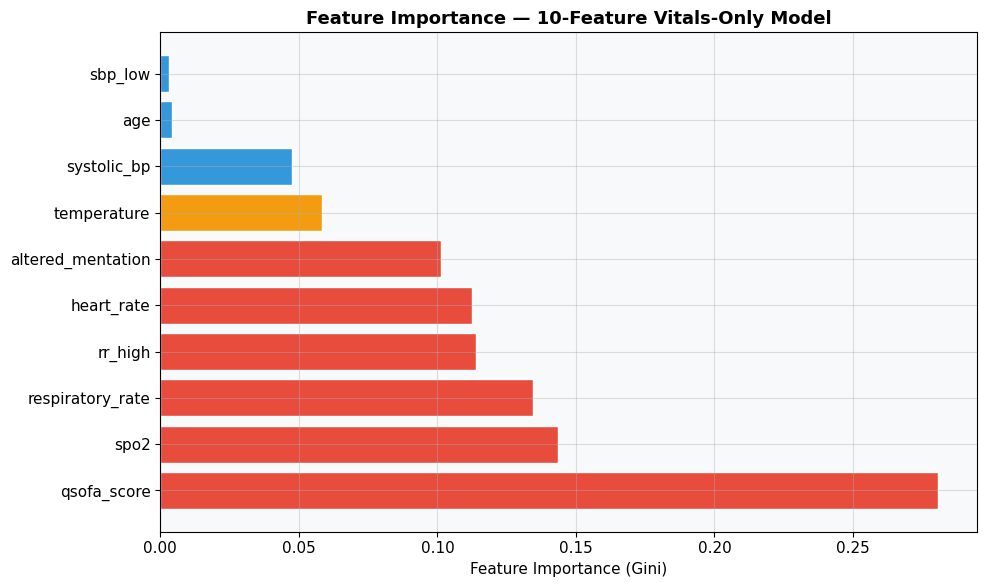

In [ ]:
feature_cols = [
    'heart_rate',
    'respiratory_rate',
    'systolic_bp',
    'temperature',
    'spo2',
    'age',
    'qsofa_score',
    'altered_mentation',
    'rr_high',
    'sbp_low'
]

X = df[feature_cols].copy()
y = df['sepsis_flag']

# Impute missing values with median before fitting
imputer = SimpleImputer(strategy='median')
X_imp   = imputer.fit_transform(X)

rf = RandomForestClassifier(
    n_estimators=200, max_depth=8,
    class_weight='balanced', random_state=42, n_jobs=-1
)

rf.fit(X_imp, y)
print("✅ Random Forest trained on 10-feature set")

importance_df = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance Ranking:")
print(importance_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = [RED if v > 0.10 else ORANGE if v > 0.05 else BLUE
          for v in importance_df['importance']]
ax.barh(importance_df['feature'], importance_df['importance'],
        color=colors, edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importance — 10-Feature Vitals-Only Model', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_feature_importance_10features.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Final Feature Set — Clinical + Statistical Rationale

In [ ]:
feature_summary = pd.DataFrame([
    # KEPT FEATURES (10 vitals-only model)
    ('heart_rate',        'Vital',       'KEEP', 'Tachycardia >90 bpm = core SIRS criterion'),
    ('respiratory_rate',  'Vital',       'KEEP', 'RR ≥22 = qSOFA criterion; direct sepsis signal'),
    ('systolic_bp',       'Vital',       'KEEP', 'Hypotension ≤100 mmHg = qSOFA criterion + shock marker'),
    ('temperature',       'Vital',       'KEEP', 'Fever >38°C or hypothermia <36°C = SIRS criterion'),
    ('spo2',              'Vital',       'KEEP', 'Low SpO2 indicates respiratory compromise in sepsis'),
    ('age',               'Demographic', 'KEEP', 'Elderly patients have significantly higher sepsis mortality'),
    ('qsofa_score',       'Engineered',  'KEEP', 'Composite qSOFA score — direct clinical sepsis screening rule'),
    ('altered_mentation', 'Engineered',  'KEEP', 'qSOFA component — altered mental status flag'),
    ('rr_high',           'Engineered',  'KEEP', 'qSOFA binary flag for respiratory rate ≥22'),
    ('sbp_low',           'Engineered',  'KEEP', 'qSOFA binary flag for systolic BP ≤100'),

    # DROPPED FEATURES (not used in 10-feature model)
    ('diastolic_bp',      'Vital',       'DROP', 'Systolic BP already captures hypotension signal; secondary'),
    ('lactate',           'Lab',         'DROP', 'Lab not available at triage; 30% missing; limits real-time use'),
    ('wbc',               'Lab',         'DROP', 'Lab not available at triage; 30% missing; limits real-time use'),
    ('creatinine',        'Lab',         'DROP', 'Lab not available at triage; 30% missing; limits real-time use'),
    ('platelet_count',    'Lab',         'DROP', 'Lab not available at triage; 30% missing; limits real-time use'),
    ('inr',               'Lab',         'DROP', 'Lab not available at triage; 30% missing; limits real-time use'),
    ('glucose',           'Lab',         'DROP', 'Lab not available at triage; 30% missing; limits real-time use'),
    ('hemoglobin',        'Lab',         'DROP', 'Lab not available at triage; 30% missing; limits real-time use'),
    ('sodium',            'Lab',         'DROP', 'Lab not available at triage; 30% missing; limits real-time use'),
    ('potassium',         'Lab',         'DROP', 'Lab not available at triage; 30% missing; limits real-time use'),
    ('pain_score',        'Vital',       'DROP', 'Non-specific for sepsis; not part of any sepsis scoring system'),
    ('troponin',          'Lab',         'DROP', 'Cardiac-specific; ~70% missing; low sepsis signal'),
    ('bnp',               'Lab',         'DROP', 'Heart-failure marker; ~70% missing; low sepsis signal'),
    ('sex',               'Demographic', 'DROP', 'No significant sepsis rate difference; excluded to avoid bias'),
    ('site_id',           'Admin',       'DROP', 'Site-level confounder — not a clinical feature'),
    ('country',           'Admin',       'DROP', 'Geographic confounder — not a clinical feature'),
    ('encounter_id',      'Admin',       'DROP', 'Unique identifier — not a feature'),
    ('patient_id',        'Admin',       'DROP', 'Unique identifier — not a feature'),
    ('arrival_timestamp', 'Admin',       'DROP', 'Administrative field — not a clinical feature'),
    ('chief_complaint',   'Text',        'DROP', 'Free text used only for label engineering (altered_mentation)'),
    ('clinical_notes',    'Text',        'DROP', 'Free text — not used in structured model pipeline'),
], columns=['feature', 'category', 'decision', 'clinical_reason'])

print("=" * 100)
print("  FEATURE SELECTION SUMMARY — 10-FEATURE VITALS-ONLY MODEL")
print("=" * 100)
print(feature_summary.to_string(index=False))
print("=" * 100)
print(f"\n✅ KEPT: 10 features (6 vitals + 1 demographic + 3 engineered)")
print(f"❌ DROPPED: 20 features (all labs removed due to ~30% missingness at triage)")
print(f"\n📌 Key advantage: Model works at triage INTAKE — no waiting for lab results")
print("=" * 100)

  FEATURE SELECTION SUMMARY — 10-FEATURE VITALS-ONLY MODEL
          feature    category decision                                                clinical_reason
       heart_rate       Vital     KEEP                      Tachycardia >90 bpm = core SIRS criterion
 respiratory_rate       Vital     KEEP                 RR ≥22 = qSOFA criterion; direct sepsis signal
      systolic_bp       Vital     KEEP         Hypotension ≤100 mmHg = qSOFA criterion + shock marker
      temperature       Vital     KEEP              Fever >38°C or hypothermia <36°C = SIRS criterion
             spo2       Vital     KEEP            Low SpO2 indicates respiratory compromise in sepsis
              age Demographic     KEEP    Elderly patients have significantly higher sepsis mortality
      qsofa_score  Engineered     KEEP  Composite qSOFA score — direct clinical sepsis screening rule
altered_mentation  Engineered     KEEP                   qSOFA component — altered mental status flag
          rr_high  Engi

In [ ]:
# ── Final selected feature list (10 FEATURES — VITALS ONLY) ───────────────
SELECTED_FEATURES = [
    # Vitals (collected at triage intake — always available)
    'heart_rate', 'respiratory_rate', 'systolic_bp',
    'temperature', 'spo2',

    # Demographics
    'age',

    # Engineered features (derived from vitals — always available)
    'qsofa_score', 'altered_mentation', 'rr_high', 'sbp_low',
]

TARGET_SEPSIS = 'sepsis_flag'   # binary 0/1        → Model A (Low/Medium/High Risk)
TARGET_ESI    = 'esi_level'     # multiclass 1–5    → Model B (ESI Level prediction)

print("=" * 70)
print("  ✅  FINAL SEPSIS MODEL FEATURE SET (10-FEATURE VITALS-ONLY)")
print("=" * 70)
print(f"  Total features    : {len(SELECTED_FEATURES)}")
print(f"  Target A (Sepsis) : {TARGET_SEPSIS}  (0 = no sepsis, 1 = sepsis)")
print(f"  Target B (ESI)    : {TARGET_ESI}  (1 = Immediate → 5 = Non-Urgent)")
print()
print(f"  Class distribution — Sepsis:")
print(f"    Positive (sepsis)    : {df[TARGET_SEPSIS].sum():,}  ({df[TARGET_SEPSIS].mean()*100:.1f}%)")
print(f"    Negative (no sepsis) : {(df[TARGET_SEPSIS]==0).sum():,}  ({(1-df[TARGET_SEPSIS].mean())*100:.1f}%)")
print()
print(f"  ESI Level distribution:")
print(df[TARGET_ESI].value_counts().sort_index().to_string())
print()
print("  Feature breakdown:")
print(f"    Vitals (always available)  : 5")
print(f"    Demographics               : 1")
print(f"    Engineered (qSOFA-based)   : 4")
print(f"    Labs (removed)             : 0  ← All labs dropped for real-time use")
print("=" * 70)

  ✅  FINAL SEPSIS MODEL FEATURE SET (10-FEATURE VITALS-ONLY)
  Total features    : 10
  Target A (Sepsis) : sepsis_flag  (0 = no sepsis, 1 = sepsis)
  Target B (ESI)    : esi_level  (1 = Immediate → 5 = Non-Urgent)

  Class distribution — Sepsis:
    Positive (sepsis)    : 8,865  (10.2%)
    Negative (no sepsis) : 78,369  (89.8%)

  ESI Level distribution:
esi_level
1      924
2    16789
3    41389
4    23199
5     4933

  Feature breakdown:
    Vitals (always available)  : 5
    Demographics               : 1
    Engineered (qSOFA-based)   : 4
    Labs (removed)             : 0  ← All labs dropped for real-time use


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score, recall_score,
    precision_score, classification_report, confusion_matrix, roc_curve
)
from xgboost import XGBClassifier
import shap
import joblib

# ── Paths
DATA_PATH = '/content/drive/MyDrive/med_data/fedmml_ed_triage_dataset.csv'
SAVE_DIR  = '/content/'

# ── Plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        11,
})
GREEN  = '#2ecc71'
RED    = '#e74c3c'
BLUE   = '#3498db'
ORANGE = '#f39c12'

print("✅ Libraries loaded")

✅ Libraries loaded


In [ ]:
DATA_PATH='/content/drive/MyDrive/med_data/fedmml_ed_triage_dataset.csv'

# Load raw CSV
df = pd.read_csv(DATA_PATH)
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Rebuild engineered features (same as EDA notebook)
mental_keywords = ['confusion', 'altered', 'unresponsive', 'drowsy',
                   'lethargic', 'high fever with confusion', 'stroke symptoms']
df['altered_mentation'] = (
    df['chief_complaint'].str.lower()
    .str.contains('|'.join(mental_keywords), na=False).astype(int)
)
df['rr_high']      = (df['respiratory_rate'] >= 22).astype(int)
df['sbp_low']      = (df['systolic_bp'] <= 100).astype(int)
df['qsofa_score']  = df['altered_mentation'] + df['rr_high'] + df['sbp_low']
df['lactate_high'] = (df['lactate'] >= 2.0).astype(int)
df['sepsis_flag']  = ((df['qsofa_score'] >= 2) | (df['lactate_high'] == 1)).astype(int)

# Selected features
SELECTED_FEATURES = [
    # Vitals (collected at triage intake — always available)
    'heart_rate', 'respiratory_rate', 'systolic_bp',
    'temperature', 'spo2',
    # Demographics
    'age',
    # Engineered features (derived from vitals — always available)
    'qsofa_score', 'altered_mentation', 'rr_high', 'sbp_low',
]
TARGET = 'sepsis_flag'

print(f"\nSepsis positive : {df[TARGET].sum():,}  ({df[TARGET].mean()*100:.1f}%)")
print(f"Sepsis negative : {(df[TARGET]==0).sum():,}  ({(1-df[TARGET].mean())*100:.1f}%)")
print(f"\n✅ Features ready")

Loaded: 87,234 rows × 28 columns

Sepsis positive : 8,865  (10.2%)
Sepsis negative : 78,369  (89.8%)

✅ Features ready


In [ ]:
continuous_features = [
    'heart_rate',
    'respiratory_rate',
    'systolic_bp',
    'temperature',
    'spo2',
    'age'
]

outlier_summary = []

for col in continuous_features:
    data = df[col].dropna()

    # IQR method
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR    = Q3 - Q1
    lower  = Q1 - 1.5 * IQR
    upper  = Q3 + 1.5 * IQR
    iqr_outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    # Z-Score method
    z_scores   = np.abs(stats.zscore(data))
    z_outliers = (z_scores > 3).sum()

    outlier_summary.append({
        'feature'      : col,
        'min'          : round(data.min(), 2),
        'max'          : round(data.max(), 2),
        'IQR_lower'    : round(lower, 2),
        'IQR_upper'    : round(upper, 2),
        'IQR_outliers' : iqr_outliers,
        'IQR_%'        : round(iqr_outliers / len(data) * 100, 2),
        'Z_outliers'   : z_outliers,
        'Z_%'          : round(z_outliers / len(data) * 100, 2),
    })

outlier_df = pd.DataFrame(outlier_summary)
print("Outlier Detection Summary:")
print(outlier_df[['feature','min','max','IQR_outliers','IQR_%','Z_outliers','Z_%']].to_string(index=False))

Outlier Detection Summary:
         feature  min   max  IQR_outliers  IQR_%  Z_outliers  Z_%
      heart_rate 31.0 183.0          1466   1.79         512 0.63
respiratory_rate  2.0  44.0          3008   3.68         890 1.09
     systolic_bp 43.0 229.0          2035   2.49         901 1.10
     temperature 34.0  41.3          2192   2.68         870 1.06
            spo2 75.4 105.1          2320   2.84         978 1.20
             age 18.0 100.0             0   0.00           0 0.00


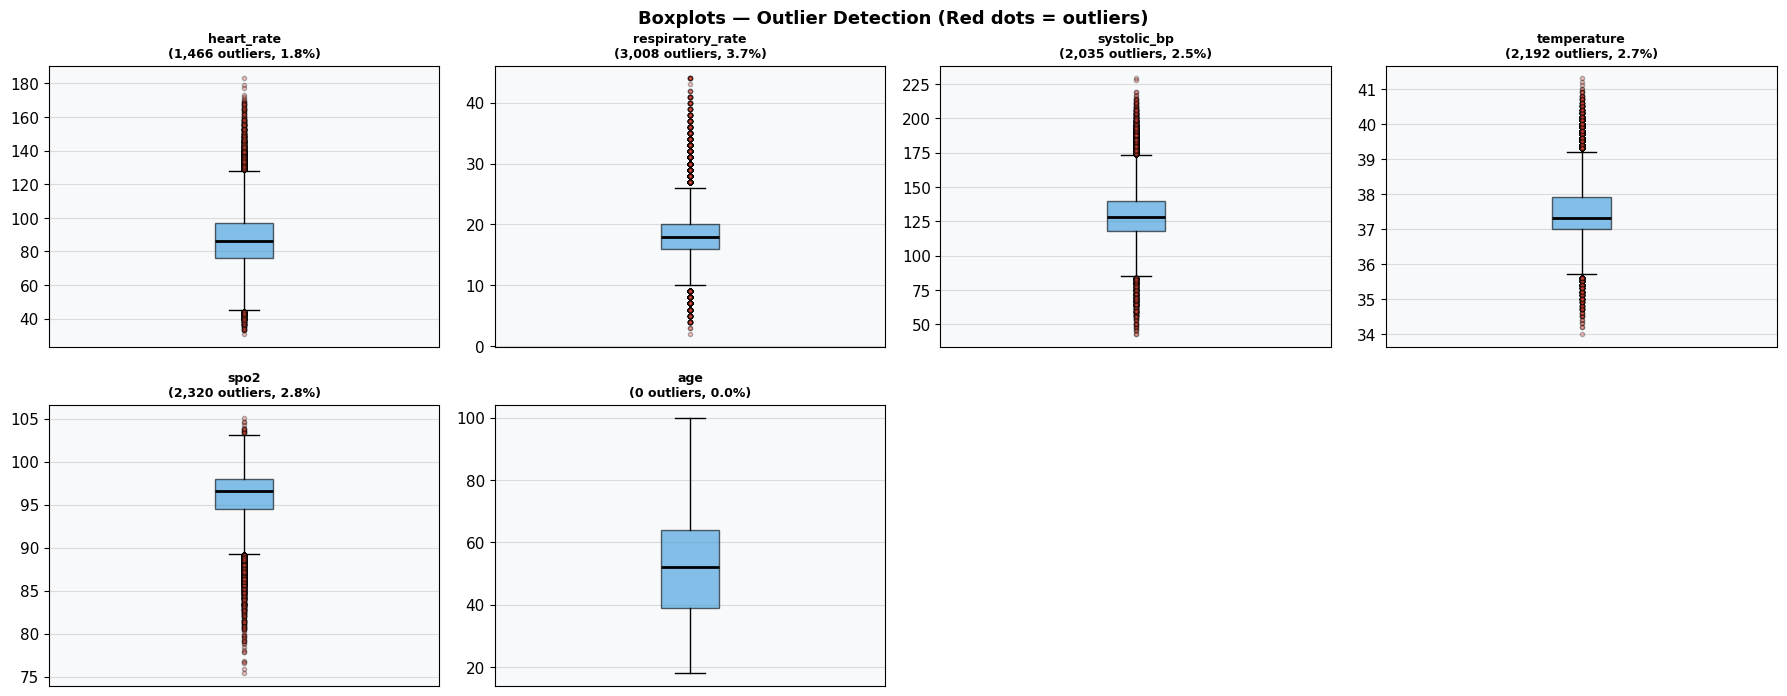

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for ax, col in zip(axes, continuous_features):
    data  = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR   = Q3 - Q1
    n_out = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()

    bp = ax.boxplot(data, vert=True, patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2},
                    flierprops={'marker': 'o', 'markerfacecolor': RED,
                                'alpha': 0.3, 'markersize': 3})
    bp['boxes'][0].set_facecolor(BLUE)
    bp['boxes'][0].set_alpha(0.6)
    ax.set_title(f'{col}\n({n_out:,} outliers, {n_out/len(data)*100:.1f}%)',
                 fontsize=9, fontweight='bold')
    ax.set_xticks([])

for ax in axes[len(continuous_features):]:
    ax.set_visible(False)

plt.suptitle('Boxplots — Outlier Detection (Red dots = outliers)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
df_clean = df.copy()
cap_log  = []

for col in continuous_features:
    lower_cap = df_clean[col].quantile(0.01)
    upper_cap = df_clean[col].quantile(0.99)

    n_low  = (df_clean[col] < lower_cap).sum()
    n_high = (df_clean[col] > upper_cap).sum()

    df_clean[col] = df_clean[col].clip(lower=lower_cap, upper=upper_cap)

    cap_log.append({
        'feature'        : col,
        'cap_lower (1%)' : round(lower_cap, 3),
        'cap_upper (99%)': round(upper_cap, 3),
        'rows_capped_low': n_low,
        'rows_capped_high': n_high,
        'total_capped'   : n_low + n_high,
    })

cap_df = pd.DataFrame(cap_log)
print("Winsorization Summary:")
print(cap_df.to_string(index=False))
print(f"\n✅ Capping done. Shape unchanged: {df_clean.shape}")

Winsorization Summary:
         feature  cap_lower (1%)  cap_upper (99%)  rows_capped_low  rows_capped_high  total_capped
      heart_rate            53.0            132.0              769               793          1562
respiratory_rate            11.0             29.0              791               785          1576
     systolic_bp            93.0            181.0              803               739          1542
     temperature            36.1             39.6              749               729          1478
            spo2            87.2            100.5              795               718          1513
             age            18.0             95.0                0               869           869

✅ Capping done. Shape unchanged: (87234, 34)


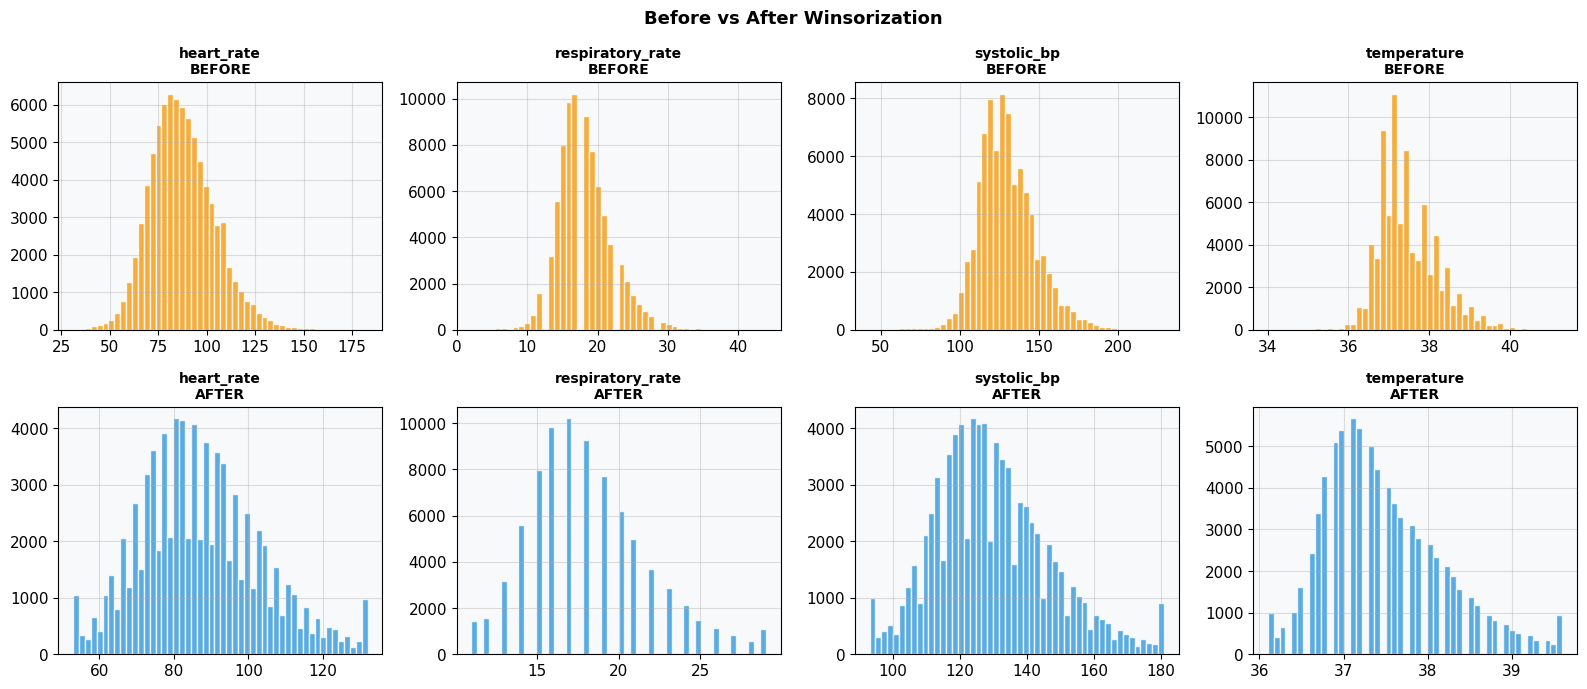

In [ ]:
check_cols = ['heart_rate', 'respiratory_rate', 'systolic_bp', 'temperature']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for i, col in enumerate(check_cols):
    axes[0, i].hist(df[col].dropna(), bins=50, color=ORANGE, alpha=0.8, edgecolor='white')
    axes[0, i].set_title(f'{col}\nBEFORE', fontweight='bold', fontsize=10)

    axes[1, i].hist(df_clean[col].dropna(), bins=50, color=BLUE, alpha=0.8, edgecolor='white')
    axes[1, i].set_title(f'{col}\nAFTER', fontweight='bold', fontsize=10)

plt.suptitle('Before vs After Winsorization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_outlier_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
X = df_clean[SELECTED_FEATURES].copy()

print(f"Total features: {X.shape[1]}")
print(f"Features used: {list(SELECTED_FEATURES)}")

# ── Split for Model A — Sepsis (binary 0/1) ───────────────────────────────
y_sepsis = df_clean[TARGET_SEPSIS].copy()
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y_sepsis, test_size=0.2, random_state=42, stratify=y_sepsis
)

# ── Split for Model B — ESI Level (1–5) ───────────────────────────────────
y_esi = df_clean[TARGET_ESI].copy()
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X, y_esi, test_size=0.2, random_state=42, stratify=y_esi
)

# ── Imputation ─────────────────────────────────────────────────────────────
imputer       = SimpleImputer(strategy='median')
X_train_s_imp = imputer.fit_transform(X_train_s)
X_test_s_imp  = imputer.transform(X_test_s)
X_train_e_imp = imputer.fit_transform(X_train_e)
X_test_e_imp  = imputer.transform(X_test_e)

# ── Scaled versions for Logistic Regression ────────────────────────────────
scaler        = StandardScaler()
X_train_s_sc  = scaler.fit_transform(X_train_s_imp)
X_test_s_sc   = scaler.transform(X_test_s_imp)
X_train_e_sc  = scaler.fit_transform(X_train_e_imp)
X_test_e_sc   = scaler.transform(X_test_e_imp)

print(f"\nModel A — Sepsis:")
print(f"  Train : {X_train_s.shape[0]:,} rows  ({y_train_s.mean()*100:.1f}% sepsis)")
print(f"  Test  : {X_test_s.shape[0]:,} rows   ({y_test_s.mean()*100:.1f}% sepsis)")
print(f"\nModel B — ESI Level:")
print(f"  Train : {X_train_e.shape[0]:,} rows")
print(f"  Test  : {X_test_e.shape[0]:,} rows")
print(f"  ESI distribution in test:\n{y_test_e.value_counts().sort_index()}")
print("\n✅ Preprocessing complete for both models")

Total features: 10
Features used: ['heart_rate', 'respiratory_rate', 'systolic_bp', 'temperature', 'spo2', 'age', 'qsofa_score', 'altered_mentation', 'rr_high', 'sbp_low']

Model A — Sepsis:
  Train : 69,787 rows  (10.2% sepsis)
  Test  : 17,447 rows   (10.2% sepsis)

Model B — ESI Level:
  Train : 69,787 rows
  Test  : 17,447 rows
  ESI distribution in test:
esi_level
1     185
2    3358
3    8278
4    4640
5     986
Name: count, dtype: int64

✅ Preprocessing complete for both models


In [ ]:
neg_pos_ratio = (y_train_s == 0).sum() / (y_train_s == 1).sum()
print(f"Class ratio (neg:pos) = {neg_pos_ratio:.1f}:1")

# xgb_sepsis = XGBClassifier(
#     n_estimators      = 300,
#     max_depth         = 6,
#     learning_rate     = 0.05,
#     subsample         = 0.8,
#     colsample_bytree  = 0.8,
#     scale_pos_weight  = neg_pos_ratio,
#     use_label_encoder = False,
#     eval_metric       = 'logloss',
#     random_state      = 42,
#     n_jobs            = -1
# )
# xgb_sepsis.fit(X_train_s_imp, y_train_s,
#                eval_set=[(X_test_s_imp, y_test_s)],
#                verbose=False)

# xgb_s_pred = xgb_sepsis.predict(X_test_s_imp)
# xgb_s_prob = xgb_sepsis.predict_proba(X_test_s_imp)[:, 1]

# print("\n✅ XGBoost Sepsis Detector trained")
# print(f"  Accuracy  : {accuracy_score(y_test_s, xgb_s_pred)*100:.2f}%")
# print(f"  ROC-AUC   : {roc_auc_score(y_test_s, xgb_s_prob):.4f}")
# print(f"  F1 Score  : {f1_score(y_test_s, xgb_s_pred):.4f}")
# print(f"  Recall    : {recall_score(y_test_s, xgb_s_pred):.4f}  ← most important for sepsis")
# print(f"  Precision : {precision_score(y_test_s, xgb_s_pred):.4f}")

Class ratio (neg:pos) = 8.8:1


In [ ]:
# rf_sepsis = RandomForestClassifier(
#     n_estimators = 300,
#     max_depth    = 10,
#     class_weight = 'balanced',
#     random_state = 42,
#     n_jobs       = -1
# )
# rf_sepsis.fit(X_train_s_imp, y_train_s)

# rf_s_pred = rf_sepsis.predict(X_test_s_imp)
# rf_s_prob = rf_sepsis.predict_proba(X_test_s_imp)[:, 1]

# print("✅ Random Forest Sepsis Detector trained")
# # print(f"  Accuracy  : {accuracy_score(y_test_s, rf_s_pred)*100:.2f}%")
# # print(f"  ROC-AUC   : {roc_auc_score(y_test_s, rf_s_prob):.4f}")
# # print(f"  F1 Score  : {f1_score(y_test_s, rf_s_pred):.4f}")
# # print(f"  Recall    : {recall_score(y_test_s, rf_s_pred):.4f}  ← most important for sepsis")
# # print(f"  Precision : {precision_score(y_test_s, rf_s_pred):.4f}")

In [ ]:
# lr_sepsis = LogisticRegression(
#     class_weight = 'balanced',
#     max_iter     = 1000,
#     random_state = 42,
#     n_jobs       = -1
# )
# lr_sepsis.fit(X_train_s_sc, y_train_s)

# lr_s_pred = lr_sepsis.predict(X_test_s_sc)
# lr_s_prob = lr_sepsis.predict_proba(X_test_s_sc)[:, 1]

# print("✅ Logistic Regression Sepsis Detector trained")
# # print(f"  Accuracy  : {accuracy_score(y_test_s, lr_s_pred)*100:.2f}%")
# # print(f"  ROC-AUC   : {roc_auc_score(y_test_s, lr_s_prob):.4f}")
# # print(f"  F1 Score  : {f1_score(y_test_s, lr_s_pred):.4f}")
# # print(f"  Recall    : {recall_score(y_test_s, lr_s_pred):.4f}  ← most important for sepsis")
# # print(f"  Precision : {precision_score(y_test_s, lr_s_pred):.4f}")

In [ ]:
# ═══════════════════════════════════════════════════
#  MODEL B — ESI LEVEL PREDICTOR (multiclass 1–5)
# ═══════════════════════════════════════════════════

# ── Fix: XGBoost needs classes starting from 0 ────────────────────────────
y_train_e_xgb = y_train_e - 1   # convert 1–5 → 0–4
y_test_e_xgb  = y_test_e  - 1   # convert 1–5 → 0–4

# XGBoost ESI
xgb_esi = XGBClassifier(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    use_label_encoder= False,
    eval_metric      = 'mlogloss',
    random_state     = 42,
    n_jobs           = -1
)
xgb_esi.fit(X_train_e_imp, y_train_e_xgb,
            eval_set=[(X_test_e_imp, y_test_e_xgb)],
            verbose=False)

# Add 1 back so predictions show 1–5 again
xgb_e_pred = xgb_esi.predict(X_test_e_imp) + 1

# Random Forest ESI (no fix needed — RF handles 1–5 fine)
rf_esi = RandomForestClassifier(
    n_estimators = 300,
    max_depth    = 10,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1
)
rf_esi.fit(X_train_e_imp, y_train_e)
rf_e_pred = rf_esi.predict(X_test_e_imp)

# Logistic Regression ESI (no fix needed)
lr_esi = LogisticRegression(
    class_weight = 'balanced',
    max_iter     = 1000,
    random_state = 42,
    n_jobs       = -1
)
lr_esi.fit(X_train_e_sc, y_train_e)
lr_e_pred = lr_esi.predict(X_test_e_sc)

# Comparison
results_esi = pd.DataFrame([
    {'Model':'XGBoost',
     'Accuracy': round(accuracy_score(y_test_e, xgb_e_pred)*100, 2)},
    {'Model':'Random Forest',
     'Accuracy': round(accuracy_score(y_test_e, rf_e_pred)*100, 2)},
    {'Model':'Logistic Regression',
     'Accuracy': round(accuracy_score(y_test_e, lr_e_pred)*100, 2)},
]).set_index('Model')

print("=" * 45)
print("  MODEL B — ESI PREDICTOR COMPARISON")
print("=" * 45)
print(results_esi.to_string())
print("=" * 45)
print(f"\n⭐ Best : {results_esi['Accuracy'].idxmax()}")
# print("\nClassification Report — XGBoost ESI:")
# print(classification_report(y_test_e, xgb_e_pred,
#       target_names=['ESI-1','ESI-2','ESI-3','ESI-4','ESI-5']))

  MODEL B — ESI PREDICTOR COMPARISON
                     Accuracy
Model                        
XGBoost                 81.91
Random Forest           71.11
Logistic Regression     66.95

⭐ Best : XGBoost


In [ ]:
# ── Risk label from sepsis probability ──────────────────────
# def get_risk_label(prob):
#     if prob >= 0.70:
#         return 'HIGH RISK ❌'
#     elif prob >= 0.40:
#         return 'MEDIUM RISK ✌'
#     else:
#         return 'LOW RISK ✅'

# ── Example combined output for one patient ────────────────────
sample      = X_test_e_imp[0].reshape(1, -1)
# sample_prob = xgb_sepsis.predict_proba(sample)[:, 1][0]
sample_esi  = xgb_esi.predict(sample)[0] + 1    # +1 converts 0–4 back to 1–5
# sample_risk = get_risk_label(sample_prob)

print("=" * 50)
print("  EXAMPLE — COMBINED OUTPUT FOR ONE PATIENT")
print("=" * 50)
# print(f"  Sepsis Probability : {sample_prob*100:.1f}%")
# print(f"  Sepsis Risk Label  : {sample_risk}")
print(f"  Predicted ESI Level: ESI-{sample_esi}")
print("=" * 50)

NameError: name 'X_test_s_imp' is not defined

## Re-categorizing ESI Levels into 3 Risk Categories

Based on your request, I will now map the 5 ESI levels into 3 risk categories:

*   **High Risk**: ESI-1 and ESI-2
*   **Medium Risk**: ESI-3
*   **Low Risk**: ESI-4 and ESI-5

We will then re-evaluate the performance of the best ESI model (XGBoost) with these new risk labels.


Classification Report — XGBoost ESI (3 Risk Categories):
              precision    recall  f1-score   support

   High Risk       0.93      0.83      0.88      3543
    Low Risk       0.88      0.84      0.86      5626
 Medium Risk       0.83      0.90      0.87      8278

    accuracy                           0.87     17447
   macro avg       0.88      0.86      0.87     17447
weighted avg       0.87      0.87      0.87     17447



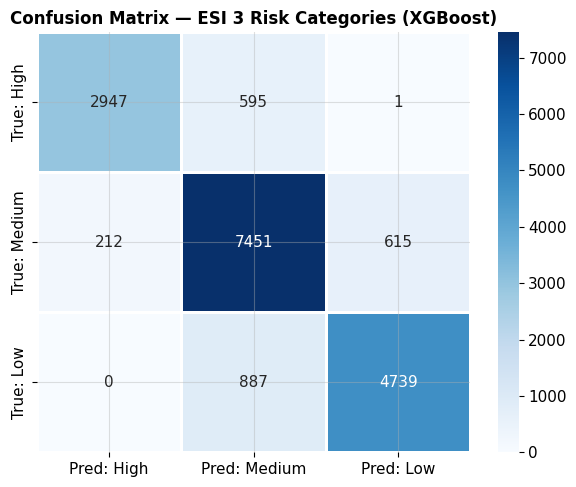

In [ ]:
def map_esi_to_risk(esi_level):
    if esi_level in [1, 2]:
        return 'High Risk'
    elif esi_level == 3:
        return 'Medium Risk'
    elif esi_level in [4, 5]:
        return 'Low Risk'
    return 'Unknown'

# Apply the mapping to the true ESI test labels and the XGBoost ESI predictions
y_test_risk       = y_test_e.apply(map_esi_to_risk)
xgb_e_pred_risk   = pd.Series(xgb_e_pred).apply(map_esi_to_risk)

print("\nClassification Report — XGBoost ESI (3 Risk Categories):")
print(classification_report(y_test_risk, xgb_e_pred_risk))

# Confusion Matrix for 3 Risk Categories
cm_risk = confusion_matrix(y_test_risk, xgb_e_pred_risk, labels=['High Risk', 'Medium Risk', 'Low Risk'])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_risk, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: High', 'Pred: Medium', 'Pred: Low'],
            yticklabels=['True: High', 'True: Medium', 'True: Low'],
            linewidths=1)
ax.set_title('Confusion Matrix — ESI 3 Risk Categories (XGBoost)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_esi_risk_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Improving Sepsis Model Precision via Threshold Adjustment

You mentioned that the current precision for the sepsis model is not ideal. It's important to understand the trade-off between **precision** and **recall** in classification models, especially for medical applications like sepsis detection:

*   **Recall** (True Positive Rate) is the ability of the model to find all positive samples. In sepsis, high recall means fewer missed sepsis cases (fewer False Negatives), which is crucial to avoid dangerous outcomes.
*   **Precision** (Positive Predictive Value) is the ability of the model to return only relevant instances. High precision means fewer false alarms (fewer False Positives). While false alarms are less dangerous than missed cases, they can lead to unnecessary resource utilization and patient anxiety.

Our current XGBoost Sepsis model prioritizes recall (0.86) over precision (0.46) to minimize missed sepsis cases. However, we can adjust the **classification threshold** to favor precision. By default, a threshold of 0.5 is used (if `probability > 0.5`, classify as positive). We can increase this threshold to make the model more conservative in its positive predictions, thus increasing precision at the likely cost of recall.

In [ ]:
# from sklearn.metrics import precision_recall_curve

# # Get probabilities from the best sepsis model (XGBoost)
# sepsis_probs = xgb_sepsis.predict_proba(X_test_s_imp)[:, 1]

# # Calculate precision-recall curve
# precision, recall, thresholds = precision_recall_curve(y_test_s, sepsis_probs)

# # Plot Precision-Recall Curve
# fig, ax = plt.subplots(figsize=(8, 6))
# ax.plot(recall, precision, color=BLUE, lw=2)
# ax.set_xlabel('Recall')
# ax.set_ylabel('Precision')
# ax.set_title('Precision-Recall Curve — XGBoost Sepsis Detector', fontweight='bold', fontsize=13)
# ax.grid(True)
# plt.tight_layout()
# plt.savefig(SAVE_DIR + 'fig_precision_recall_curve.png', dpi=150, bbox_inches='tight')
# plt.show()

# print("\n--- Metrics at different thresholds for Sepsis Model ---")

# # Example: Find a threshold for a target precision (e.g., 60% precision)
# target_precision = 0.60
# closest_threshold_idx = np.where(precision >= target_precision)[0][0]
# optimal_threshold     = thresholds[closest_threshold_idx]

# # Make predictions with the new threshold
# custom_threshold_pred = (sepsis_probs >= optimal_threshold).astype(int)

# print(f"\nMetrics at original 0.5 threshold:")
# print(f"  Precision : {precision_score(y_test_s, (sepsis_probs >= 0.5).astype(int)):.4f}")
# print(f"  Recall    : {recall_score(y_test_s, (sepsis_probs >= 0.5).astype(int)):.4f}")
# print(f"  F1 Score  : {f1_score(y_test_s, (sepsis_probs >= 0.5).astype(int)):.4f}")

# print(f"\nMetrics at custom threshold {optimal_threshold:.4f} (aiming for >= {target_precision*100:.0f}% Precision):")
# print(f"  Precision : {precision_score(y_test_s, custom_threshold_pred):.4f}")
# print(f"  Recall    : {recall_score(y_test_s, custom_threshold_pred):.4f}")
# print(f"  F1 Score  : {f1_score(y_test_s, custom_threshold_pred):.4f}")
# print("\nAs you can see, increasing the threshold typically increases precision but decreases recall.")
# print("The optimal threshold depends on the specific clinical priorities (e.g., minimizing false alarms vs. minimizing missed cases).")

In [ ]:
# results_sepsis = pd.DataFrame([
#     {'Model':'XGBoost',
#      'Accuracy': round(accuracy_score(y_test_s, xgb_s_pred)*100, 2),
#      'ROC-AUC' : round(roc_auc_score(y_test_s, xgb_s_prob), 4),
#      'F1'      : round(f1_score(y_test_s, xgb_s_pred), 4),
#      'Recall'  : round(recall_score(y_test_s, xgb_s_pred), 4),
#      'Precision': round(precision_score(y_test_s, xgb_s_pred), 4)},
#     {'Model':'Random Forest',
#      'Accuracy': round(accuracy_score(y_test_s, rf_s_pred)*100, 2),
#      'ROC-AUC' : round(roc_auc_score(y_test_s, rf_s_prob), 4),
#      'F1'      : round(f1_score(y_test_s, rf_s_pred), 4),
#      'Recall'  : round(recall_score(y_test_s, rf_s_pred), 4),
#      'Precision': round(precision_score(y_test_s, rf_s_pred), 4)},
#     {'Model':'Logistic Regression',
#      'Accuracy': round(accuracy_score(y_test_s, lr_s_pred)*100, 2),
#      'ROC-AUC' : round(roc_auc_score(y_test_s, lr_s_prob), 4),
#      'F1'      : round(f1_score(y_test_s, lr_s_pred), 4),
#      'Recall'  : round(recall_score(y_test_s, lr_s_pred), 4),
#      'Precision': round(precision_score(y_test_s, lr_s_pred), 4)},
# ]).set_index('Model')

# print("=" * 65)
# print("  MODEL A — SEPSIS DETECTOR COMPARISON")
# print("=" * 65)
# print(results_sepsis.to_string())
# print("=" * 65)
# print("\n⭐ Best ROC-AUC   :", results_sepsis['ROC-AUC'].idxmax())
# print("⭐ Best Recall     :", results_sepsis['Recall'].idxmax())
# print("⭐ Best F1 Score   :", results_sepsis['F1'].idxmax())

In [ ]:
# fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# model_names = ['XGBoost', 'Random Forest', 'Logistic Reg.']
# bar_colors  = [RED, BLUE, ORANGE]

# metrics = {
#     'ROC-AUC' : [roc_auc_score(y_test_s, xgb_s_prob),
#                  roc_auc_score(y_test_s, rf_s_prob),
#                  roc_auc_score(y_test_s, lr_s_prob)],
#     'F1 Score': [f1_score(y_test_s, xgb_s_pred),
#                  f1_score(y_test_s, rf_s_pred),
#                  f1_score(y_test_s, lr_s_pred)],
#     'Recall'  : [recall_score(y_test_s, xgb_s_pred),
#                  recall_score(y_test_s, rf_s_pred),
#                  recall_score(y_test_s, lr_s_pred)],
# }

# for ax, (metric_name, values) in zip(axes, metrics.items()):
#     bars = ax.bar(model_names, values, color=bar_colors,
#                   edgecolor='white', linewidth=1.5)
#     for bar, val in zip(bars, values):
#         ax.text(bar.get_x() + bar.get_width()/2,
#                 bar.get_height() + 0.005,
#                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)
#     ax.set_ylim(0, min(1.0, max(values) * 1.15))
#     ax.set_title(metric_name, fontweight='bold', fontsize=13)
#     ax.set_ylabel('Score')

# plt.suptitle('Model A — Sepsis Detector Comparison',
#              fontsize=13, fontweight='bold')
# plt.tight_layout()
# plt.savefig(SAVE_DIR + 'fig_model_comparison.png', dpi=150, bbox_inches='tight')
# plt.show()

In [ ]:
# fig, ax = plt.subplots(figsize=(8, 7))

# for name, prob, color in [
#     ('XGBoost',             xgb_s_prob, RED),
#     ('Random Forest',       rf_s_prob,  BLUE),
#     ('Logistic Regression', lr_s_prob,  ORANGE),
# ]:
#     fpr, tpr, _ = roc_curve(y_test_s, prob)
#     auc         = roc_auc_score(y_test_s, prob)
#     ax.plot(fpr, tpr, color=color, lw=2.5,
#             label=f'{name}  (AUC = {auc:.4f})')

# ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Random baseline')
# ax.set_xlabel('False Positive Rate')
# ax.set_ylabel('True Positive Rate (Recall)')
# ax.set_title('ROC Curves — Model A Sepsis Detector',
#              fontweight='bold', fontsize=13)
# ax.legend(fontsize=11)
# plt.tight_layout()
# plt.savefig(SAVE_DIR + 'fig_roc_curves.png', dpi=150, bbox_inches='tight')
# plt.show()

In [ ]:
# fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# for ax, (name, pred) in zip(axes, [
#     ('XGBoost',             xgb_s_pred),
#     ('Random Forest',       rf_s_pred),
#     ('Logistic Regression', lr_s_pred),
# ]):
#     cm = confusion_matrix(y_test_s, pred)
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
#                 xticklabels=['Pred: No Sepsis', 'Pred: Sepsis'],
#                 yticklabels=['True: No Sepsis', 'True: Sepsis'],
#                 linewidths=1)
#     tn, fp, fn, tp = cm.ravel()
#     ax.set_title(f'{name}\nTP={tp:,}  FN={fn:,}  FP={fp:,}  TN={tn:,}',
#                  fontweight='bold', fontsize=10)

# plt.suptitle('Confusion Matrices — Model A Sepsis Detector',
#              fontsize=13, fontweight='bold')
# plt.tight_layout()
# plt.savefig(SAVE_DIR + 'fig_confusion_matrices.png', dpi=150, bbox_inches='tight')
# plt.show()
# print("\n📌 FN = sepsis missed (dangerous) | FP = false alarm (acceptable)")

In [ ]:
# for name, pred in [('XGBoost',             xgb_s_pred),
#                    ('Random Forest',        rf_s_pred),
#                    ('Logistic Regression',  lr_s_pred)]:
#     print("=" * 50)
#     print(f"CLASSIFICATION REPORT — {name}")
#     print("=" * 50)
#     print(classification_report(y_test_s, pred,
#           target_names=['No Sepsis', 'Sepsis']))

In [ ]:
feature_names_full = list(X_train_s.columns)

# explainer   = shap.TreeExplainer(xgb_sepsis)
# shap_values = explainer.shap_values(X_test_s_imp[:500])

# shap.summary_plot(shap_values, X_test_s_imp[:500],
#                   feature_names=feature_names_full,
#                   show=True)

In [ ]:
# ── Model A — Sepsis Detector ──────────────────────────────────────────────
# joblib.dump(xgb_sepsis, SAVE_DIR + 'sepsis_xgb_modelA.pkl')
# joblib.dump(rf_sepsis,  SAVE_DIR + 'sepsis_rf_modelA.pkl')
# joblib.dump(lr_sepsis,  SAVE_DIR + 'sepsis_lr_modelA.pkl')

# ── Model B — ESI Predictor ────────────────────────────────────────────────
joblib.dump(xgb_esi,    SAVE_DIR + 'esi_xgb_modelB.pkl')
joblib.dump(rf_esi,     SAVE_DIR + 'esi_rf_modelB.pkl')
joblib.dump(lr_esi,     SAVE_DIR + 'esi_lr_modelB.pkl')

# ── Preprocessors ──────────────────────────────────────────────────────────
joblib.dump(imputer,    SAVE_DIR + 'sepsis_imputer.pkl')
joblib.dump(scaler,     SAVE_DIR + 'sepsis_scaler.pkl')

print("✅ All models saved to HCAI folder:")
# print("   Model A (Sepsis) → sepsis_xgb_modelA.pkl")
# print("                      sepsis_rf_modelA.pkl")
# print("                      sepsis_lr_modelA.pkl")
print("   Model B (ESI)    → esi_xgb_modelB.pkl")
print("                      esi_rf_modelB.pkl")
print("                      esi_lr_modelB.pkl")
print("   Preprocessors    → sepsis_imputer.pkl")
print("                      sepsis_scaler.pkl")
print("\n" + "=" * 60)
print("  MODELS COMPLETE")
print("=" * 60)
print(f"  Features used      : {len(SELECTED_FEATURES)}")
print(f"  Training samples   : {X_train_s.shape[0]:,}")
print(f"  Test samples       : {X_test_s.shape[0]:,}")
print(f"  Class imbalance    : 1 sepsis : {(y_train_s==0).sum() / (y_train_s==1).sum():.1f} no-sepsis")
print()
# print("  Model A — Sepsis Detector:")
# print(f"    XGBoost Recall   : {recall_score(y_test_s, xgb_s_pred):.4f}")
# print(f"    XGBoost Accuracy : {accuracy_score(y_test_s, xgb_s_pred)*100:.2f}%")
print("\n  Model B — ESI Predictor:")
print(f"    XGBoost Accuracy : {accuracy_score(y_test_e, xgb_e_pred)*100:.2f}%")
print()
print("  ✅ Ready for integration into your triage system!")
print("=" * 60)

✅ All models saved to HCAI folder:
   Model B (ESI)    → esi_xgb_modelB.pkl
                      esi_rf_modelB.pkl
                      esi_lr_modelB.pkl
   Preprocessors    → sepsis_imputer.pkl
                      sepsis_scaler.pkl

  MODELS COMPLETE
  Features used      : 10
  Training samples   : 69,787
  Test samples       : 17,447
  Class imbalance    : 1 sepsis : 8.8 no-sepsis


  Model B — ESI Predictor:
    XGBoost Accuracy : 81.91%

  ✅ Ready for integration into your triage system!
